# Hangover 🥂
### "As goes January, so goes the year" — does the omen actually know anything?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predicts the year?: Not supported](https://img.shields.io/badge/Predicts_the_year%3F-Not_supported-8b949e?style=flat-square)

Wall Street's oldest calendar superstition says a green January means a bullish year. The headline sounds airtight — *up 87% of the time after an up January!* — but the rest of the year is up most of the time **no matter what January did**. We check whether the omen beats simply betting "stocks go up".

> 📓 **Plain-language layer.** The base-rate maths and the decay are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (hangover/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from quantlab.repro import as_of
from hangover import data, strategy as st
ret = as_of(data.fetch_index().to_frame())["ret"]   # cache-first, pinned to the as-of; ^GSPC is price-only
tbill = data.fetch_tbill()                          # ^IRX, for the cash years (zero pre-1960)
cash = st.cash_roy(as_of(tbill.to_frame())["tbill"]) if not tbill.empty else None
tbl = st.annual_table(ret)
cm  = st.conditional_means(tbl)
bar, bh = st.barometer_returns(tbl, cash), st.buy_hold_roy(tbl)


## The answer first 🎯

| The pitch | The catch |
|---|---|
| "Up 87% of the time after an up January" | The rest of the year is up **76% of the time anyway**. |
| "January predicts the year" | Its accuracy (**68%**) is **worse** than always saying "up" (76%). |
| "So trade the omen" | Going to T-bills after a down January just **holds less stock** — not timing. |

## 1 · The claim

Yale Hirsch, 1972: if the S&P 500 rises in January, the remaining eleven months are bullish; if January is red, watch out. Quoted every February on financial TV.

## 2 · So what?

If a single month genuinely forecasts the next eleven, that's a free market-timing signal anyone can run. If it's a statistical mirage dressed up by the fact that markets mostly rise, then millions anchor each year on noise.

## 3 · How would we even know?

The trap is the **base rate**. "Up 87% after an up January" means nothing unless you compare it to how often the year is up *regardless*. So we score the omen's **directional accuracy** against the base rate of always predicting "up", on the S&P 500 back to 1950.

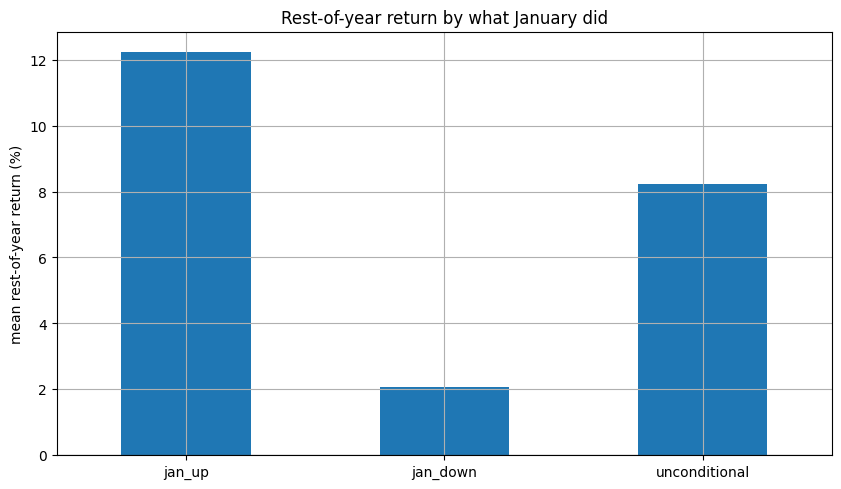

P(rest-of-year up): {'jan_up': np.float64(0.87), 'jan_down': np.float64(0.6), 'unconditional': np.float64(0.763)}


In [2]:
ax = cm[['roy_mean']].mul(100).plot.bar(legend=False, rot=0,
        title='Rest-of-year return by what January did')
ax.set_ylabel('mean rest-of-year return (%)'); ax.axhline(0,color='k',lw=.8); plt.show()
print('P(rest-of-year up):', {k: round(cm.loc[k,'p_up'],3) for k in cm.index})

## 4 · The teardown

The rest of the year is positive after an up January **and** after a down one. The only real difference is *how* positive — and with only 30 down-Januaries to learn from, we put error bars on everything.

In [3]:
acc, base = st.barometer_accuracy(tbl), st.base_rate(tbl)
print(f'Barometer directional accuracy: {acc:.1%}')
print(f'Always predict "up" base rate:  {base:.1%}')
print('The omen is %s the constant.' % ('BEATEN BY' if acc < base else 'better than'))
sp = st.split_tests(tbl)
print(f"Up-vs-down January split: Fisher p={sp['fisher_p']:.3f}, mean-gap permutation p={sp['mean_perm_p']:.3f}")
print('-> the down-January softness is real, but it is the only thing here that is.')

Barometer directional accuracy: 68.4%
Always predict "up" base rate:  76.3%
The omen is BEATEN BY the constant.


Up-vs-down January split: Fisher p=0.012, mean-gap permutation p=0.002
-> the down-January softness is real, but it is the only thing here that is.


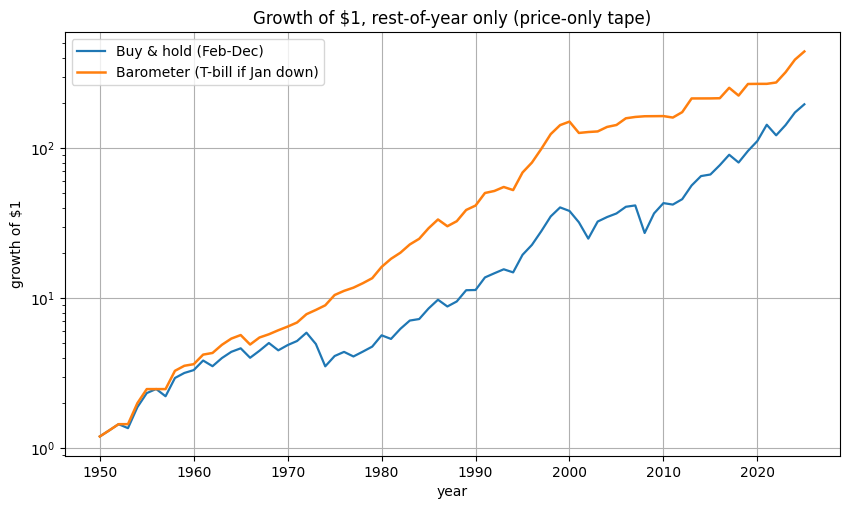

In [4]:
eq_bar=(1+bar).cumprod(); eq_bh=(1+bh).cumprod()
ax=eq_bh.plot(label='Buy & hold (Feb-Dec)',lw=1.6)
eq_bar.plot(ax=ax,label='Barometer (T-bill if Jan down)',lw=1.8)
ax.set_yscale('log'); ax.set_title('Growth of $1, rest-of-year only (price-only tape)'); ax.set_ylabel('growth of $1'); ax.legend(); plt.show()

## 5 · The verdict

**Signal: Weak** — a down January does flag a softer year, faintly but measurably (Fisher p ≈ 0.01). **Tradability: Mirage** — "trading" it just means owning less stock that year, and its return edge lives on a dividend-free tape. **Predicts the year?: Not supported** — as a forecaster it loses to a constant.

## 6 · Could you actually trade it?

You could (one decision a year, trivial), but you shouldn't expect timing: the T-bill-after-down-January rule earns its lower risk purely by being out of the market — exactly what holding a smaller equity weight does, minus the suspense. And mind the tape: this race is **price-only**. Add dividends (~3–4%/yr, which buy-and-hold collects every year and the rule only when invested) and the omen's CAGR edge disappears.

## 7 · Going further 🚪

The quants notebook splits 1950–1972 vs 1973-on (the omen *looks* fainter after Hirsch named it, though the samples are too small to prove a fade) and shows why the exposure-reduction "edge" isn't one. Next on the calendar-anomaly bench: [Study 42 Last-Call](../../42-last-call/) — the turn-of-the-month effect, which is *real* but too small to trade.